In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Path Dataset
dataset_path = '../data/raw/student_dropout_prediction.csv'
print(" Library & Dataset Berhasil Disiapkan.")


 Library & Dataset Berhasil Disiapkan.


### Fase 1: Data Loading 
Melihat profil data awal dan distribusi target.

[*] AUDIT REPORT FASE 1: student_dropout_prediction.csv
[*] Shape: 4424 baris x 35 kolom


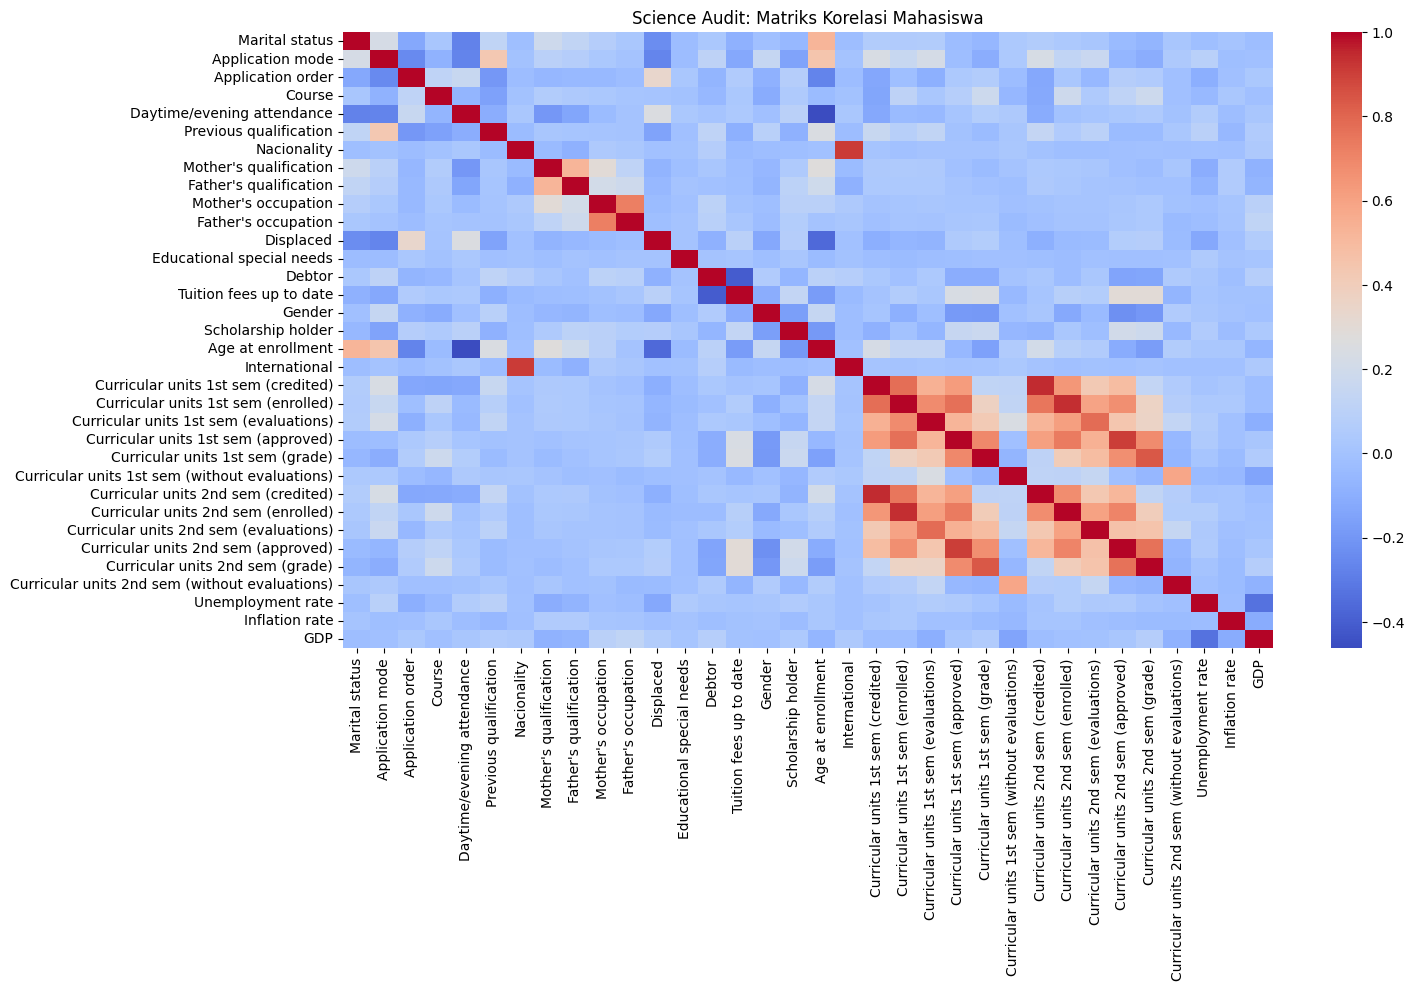

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# 1. Load Data dengan auto-separator
try:
    df = pd.read_csv(dataset_path, sep=';')
    if len(df.columns) < 2:
        df = pd.read_csv(dataset_path, sep=',')
except:
    df = pd.read_csv(dataset_path)

# Bersihkan nama kolom
df.columns = [c.strip() for c in df.columns]

# PAKSA konversi kolom angka (Ganti 'ignore' jadi 'coerce') -> ubah kolom jadi angka.
# Semisal ketemu tulisan uknown, null, typo itu diubah ke Nan / kosong
for col in df.columns:
    if col != 'Target':
        # 'coerce' akan merubah teks yang bukan angka jadi NaN supaya tidak error
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"[*] AUDIT REPORT FASE 1: {os.path.basename(dataset_path)}")
print(f"[*] Shape: {df.shape[0]} baris x {df.shape[1]} kolom")


# Ambil hanya kolom numerik -> Karena teknik Pearson Correlation yang digunakan dalam Heatmap ini bekerja berdasarkan perhitungan matematis (kovarians dan deviasi standar)
# untuk mengukur tingkat kekuatan hubungan linier antar variabel
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    plt.figure(figsize=(15, 8))
    sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
    plt.title('Science Audit: Matriks Korelasi Mahasiswa')
    plt.show()
else:
    print("[WARN] Tidak ditemukan kolom numerik!")

display(df.head())


### Fase 2: Data Preparation (7 Teknik)
Proses pembersihan, imputasi, dan splitting data.

In [3]:

target_temp = df['Target'].copy()
df_features = df.drop(['Target'], axis=1)
df_features = df_features.dropna(axis=1, how='all')

num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df_features[num_cols] = SimpleImputer(strategy='median').fit_transform(df_features[num_cols])

# 3. Gabungkan kembali
df = df_features.copy()
df['Target'] = target_temp

# 4. Define X and y
X = df.drop(['Target'], axis=1)
le = LabelEncoder()
y = le.fit_transform(df['Target'])
print(f"[*] Target Classes Encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Buang ID
for col in ['student_id', 'id', 'STUDENT_ID']:
    if col in X.columns: X = X.drop(col, axis=1)

# 5. SPLITTING (Cek data sebelum split)
if len(df) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"✅ Preprocessing Selesai! Data Latih: {len(X_train)} baris.")
else:
    print("❌ ERROR: Data kosong! Silakan jalankan ulang Cell LOAD DATA di atas.")


[*] Target Classes Encoded: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
✅ Preprocessing Selesai! Data Latih: 3539 baris.


### Fase 3: Advanced Feature Engineering
Ekstraksi fitur baru 

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Identifikasi Fitur Kategori
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

# 2. Transformasi (OHE)
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
], remainder='passthrough')

X_train_t = ct.fit_transform(X_train)
X_test_t = ct.transform(X_test)

# 3. Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_t)
X_test_s = scaler.transform(X_test_t)

# 4. Feature Selection (Top 30)
# Pastikan k tidak lebih besar dari jumlah kolom yang ada
num_features = X_train_s.shape[1]
k_best = min(30, num_features)

selector = SelectKBest(f_classif, k=k_best)
X_train_final = selector.fit_transform(X_train_s, y_train)
X_test_final = selector.transform(X_test_s)

print(f" Feature Selection: {k_best} Fitur Transparan Terpilih.")


 Feature Selection: 30 Fitur Transparan Terpilih.


###  Fase 4: Modeling 
Pelatihan 3 Model Terbaik

In [ ]:

print("\n--- FASE 4: MODELING (SMOTE & TOP 3) ---")

# SMOTE 
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_final, y_train)
print(f"[✓] SMOTE Selesai. Dataset Seimbang: {len(y_res)} sampel.")

# Training
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f"[*] Training {name}...")
    model.fit(X_res, y_res)
    trained_models[name] = model

print(" Training 3 Model Terbaik Selesai.")



--- FASE 4: MODELING (SMOTE & TOP 3) ---
[✓] SMOTE Selesai. Dataset Seimbang: 5301 sampel.
[*] Training Random Forest...
[*] Training XGBoost...
[*] Training Gradient Boosting...
 Training 3 Model Terbaik Selesai.


###  Fase 5: Model Evaluation and Visualization
Model Evaluation

,Model,Accuracy,F1-Score
3,Penelitian Sebelumnya (Baseline),0.9100,0.9000
0,Random Forest,0.7684,0.7674
1,XGBoost,0.7650,0.7599
2,Gradient Boosting,0.7605,0.7612


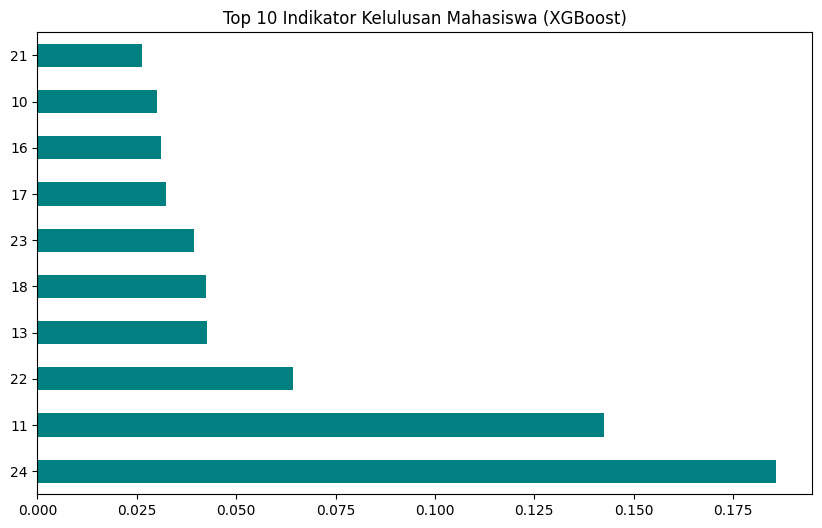

In [6]:
# Logika dari evaluate.py (Dashboard & Baseline)
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_final)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred, average='weighted'), 4)
    })

# Baseline Penelitian Sebelumnya (Poin Perbandingan)
results.append({'Model': 'Penelitian Sebelumnya (Baseline)', 'Accuracy': 0.9100, 'F1-Score': 0.9000})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
display(results_df)

# Visualisasi Feature Importance (Audit Transparansi)
best_model = trained_models["XGBoost"]
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_model.feature_importances_, index=range(30))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Indikator Kelulusan Mahasiswa (XGBoost)')
plt.show()
